# EDA — Fake Social Media (engineered features)

**File:** `data/fake_social_media.csv`

This dataset contains engineered social-media account features with a binary
target **`is_fake`** (1 = fake account, 0 = real account). It is the
modeling-ready dataset for the fake-account detection task.

Plan:
1. Load and first look
2. Missing values
3. Duplicates
4. Target analysis (class balance)
5. Numeric feature analysis
6. Categorical features
7. Feature behaviour by class + correlation with target
8. Key observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../data/fake_social_media.csv"
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
df.head()

Rows: 3,000  Columns: 18


,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake
0,Twitter,1,180,1,431,679,0.633824,941,194,0.205945,0.699444,0.243579,456,44,63,1,1,1
1,Instagram,1,214,0,426,729,0.583562,3164,202,0.063823,0.538005,0.122000,98,196,79,0,0,1
2,Twitter,1,87,0,426,721,0.590028,903,225,0.248894,0.858450,0.835424,136,171,139,0,1,1
3,Twitter,0,72,0,385,679,0.566176,3433,175,0.050961,0.176471,0.916446,186,46,72,1,1,1
4,Instagram,0,162,1,392,709,0.552113,1269,207,0.162992,0.265957,0.214862,35,184,138,1,0,1


## 1. First look — structure, dtypes, samples

In [2]:
df.info()
df.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  3000 non-null   str    
 1   has_profile_pic           3000 non-null   int64  
 2   bio_length                3000 non-null   int64  
 3   username_randomness       3000 non-null   int64  
 4   followers                 3000 non-null   int64  
 5   following                 3000 non-null   int64  
 6   follower_following_ratio  3000 non-null   float64
 7   account_age_days          3000 non-null   int64  
 8   posts                     3000 non-null   int64  
 9   posts_per_day             3000 non-null   float64
 10  caption_similarity_score  3000 non-null   float64
 11  content_similarity_score  3000 non-null   float64
 12  follow_unfollow_rate      3000 non-null   int64  
 13  spam_comments_rate        3000 non-null   int64  
 14  generic_comment_rat

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake
1801,Facebook,0,45,0,405,724,0.558621,904,196,0.216575,0.094620,0.830365,439,80,4,1,1,1
1190,Instagram,0,28,1,392,710,0.551336,1005,230,0.228628,0.540781,0.061101,189,154,123,0,1,1
1817,Twitter,0,24,1,410,678,0.603829,3312,211,0.063688,0.898189,0.472268,137,18,66,0,1,1
251,Twitter,0,176,1,403,677,0.594395,2206,203,0.091980,0.030437,0.867300,208,80,146,1,0,1
2505,Twitter,1,64,0,369,678,0.543446,962,200,0.207684,0.186578,0.021747,187,192,58,0,0,1


## 2. Missing values

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
print(f"Columns with missing values: {len(missing_tbl)} / {df.shape[1]}")
missing_tbl


Columns with missing values: 0 / 18


,missing_count,missing_pct


In [4]:
if missing_tbl.empty:
    print("No missing values in this dataset.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_tbl))))
    missing_tbl["missing_pct"].sort_values().plot.barh(ax=ax, color="tomato")
    ax.set_xlabel("% missing")
    ax.set_title("Missing values per column")
    plt.tight_layout()
    plt.show()


No missing values in this dataset.


## 3. Duplicates

In [5]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
if "id" in df.columns:
    print(f"Duplicated 'id' values: {df['id'].duplicated().sum()}")
    print("Most frequent ids:")
    display(df["id"].value_counts().head(10))


Fully duplicated rows: 0


## 4. Target analysis — class balance

is_fake
1    2993
0       7
Name: count, dtype: int64

Fraud rate: 99.77% fake accounts


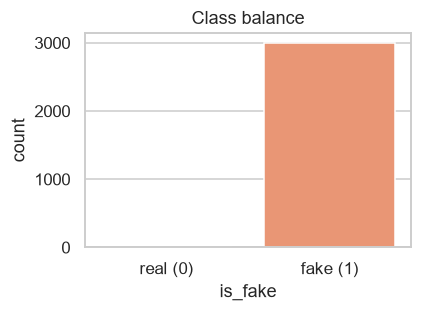

In [6]:
label_col = "is_fake"
counts = df[label_col].value_counts()
print(counts)
print(f"\nFraud rate: {df[label_col].mean() * 100:.2f}% fake accounts")

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(x=label_col, data=df, ax=ax, hue=label_col, palette="Set2", legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["real (0)", "fake (1)"])
ax.set_title("Class balance")
plt.tight_layout()
plt.show()


## 5. Numeric feature analysis

In [7]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns ({len(num_cols)}):")
display(df[num_cols].describe().T.round(3))


Numeric columns (17):

,count,mean,std,min,25%,50%,75%,max
has_profile_pic,3000.0,0.489,0.500,0.000,0.000,0.000,1.000,1.000
bio_length,3000.0,125.231,71.511,0.000,66.000,125.000,186.000,249.000
username_randomness,3000.0,0.507,0.500,0.000,0.000,1.000,1.000,1.000
followers,3000.0,399.934,20.045,334.000,386.000,400.000,413.000,472.000
following,3000.0,700.673,25.897,607.000,684.000,701.000,718.000,789.000
follower_following_ratio,3000.0,0.571,0.035,0.467,0.546,0.570,0.594,0.694
account_age_days,3000.0,2492.011,1431.540,2.000,1255.750,2462.500,3733.250,4997.000
posts,3000.0,200.255,14.271,151.000,190.000,200.000,209.000,254.000
posts_per_day,3000.0,0.274,1.660,0.034,0.054,0.082,0.158,73.333
caption_similarity_score,3000.0,0.501,0.287,0.000,0.255,0.506,0.747,1.000


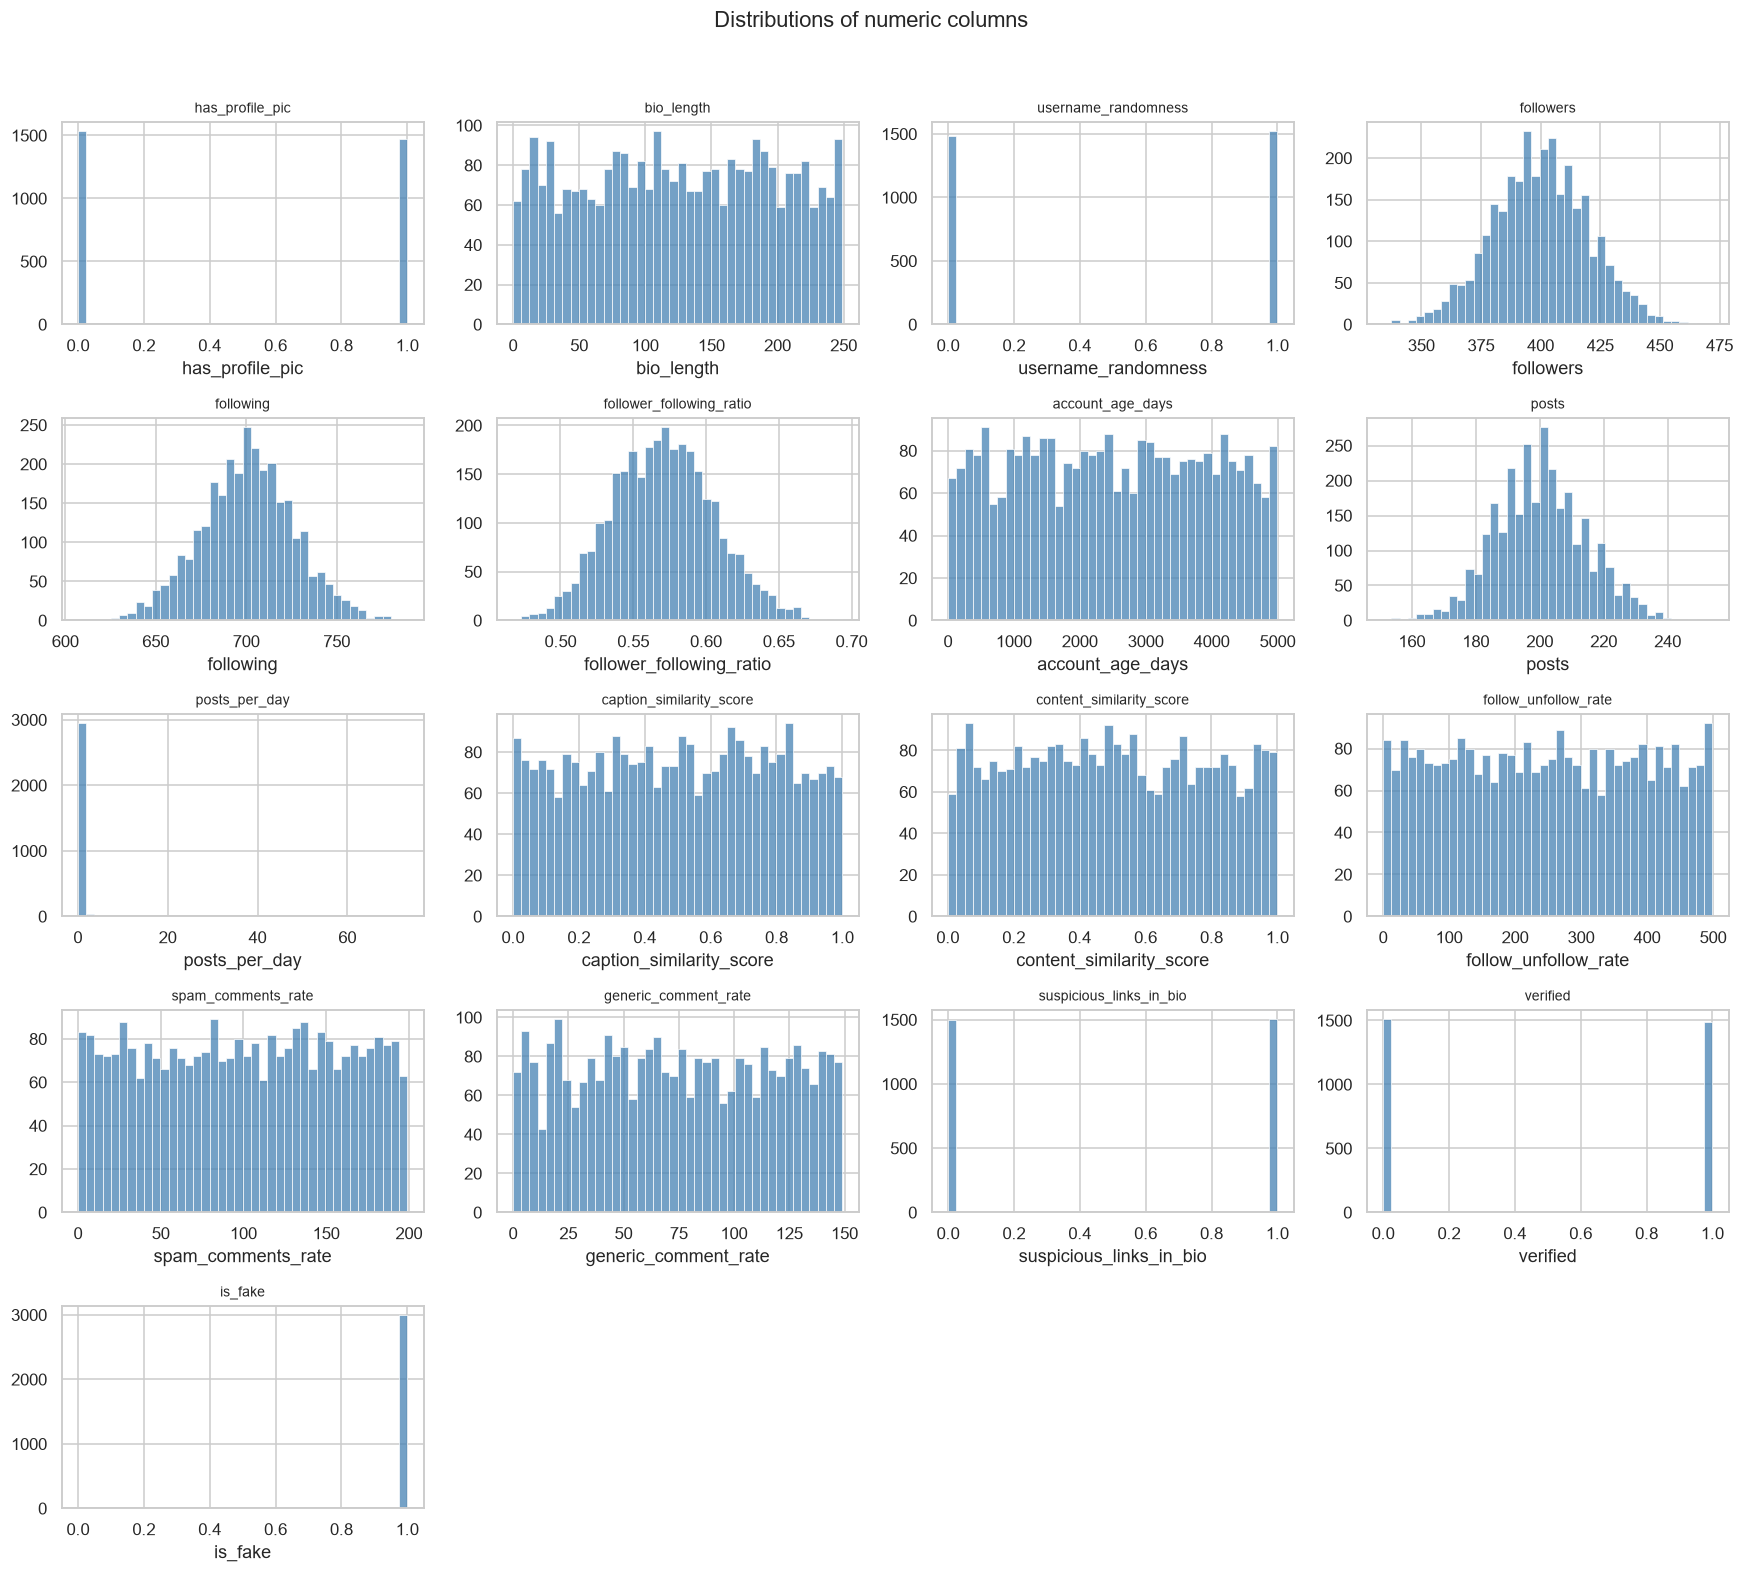

In [8]:
n = len(num_cols)
ncols = min(n, 4)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Distributions of numeric columns", y=1.02)
plt.tight_layout()
plt.show()


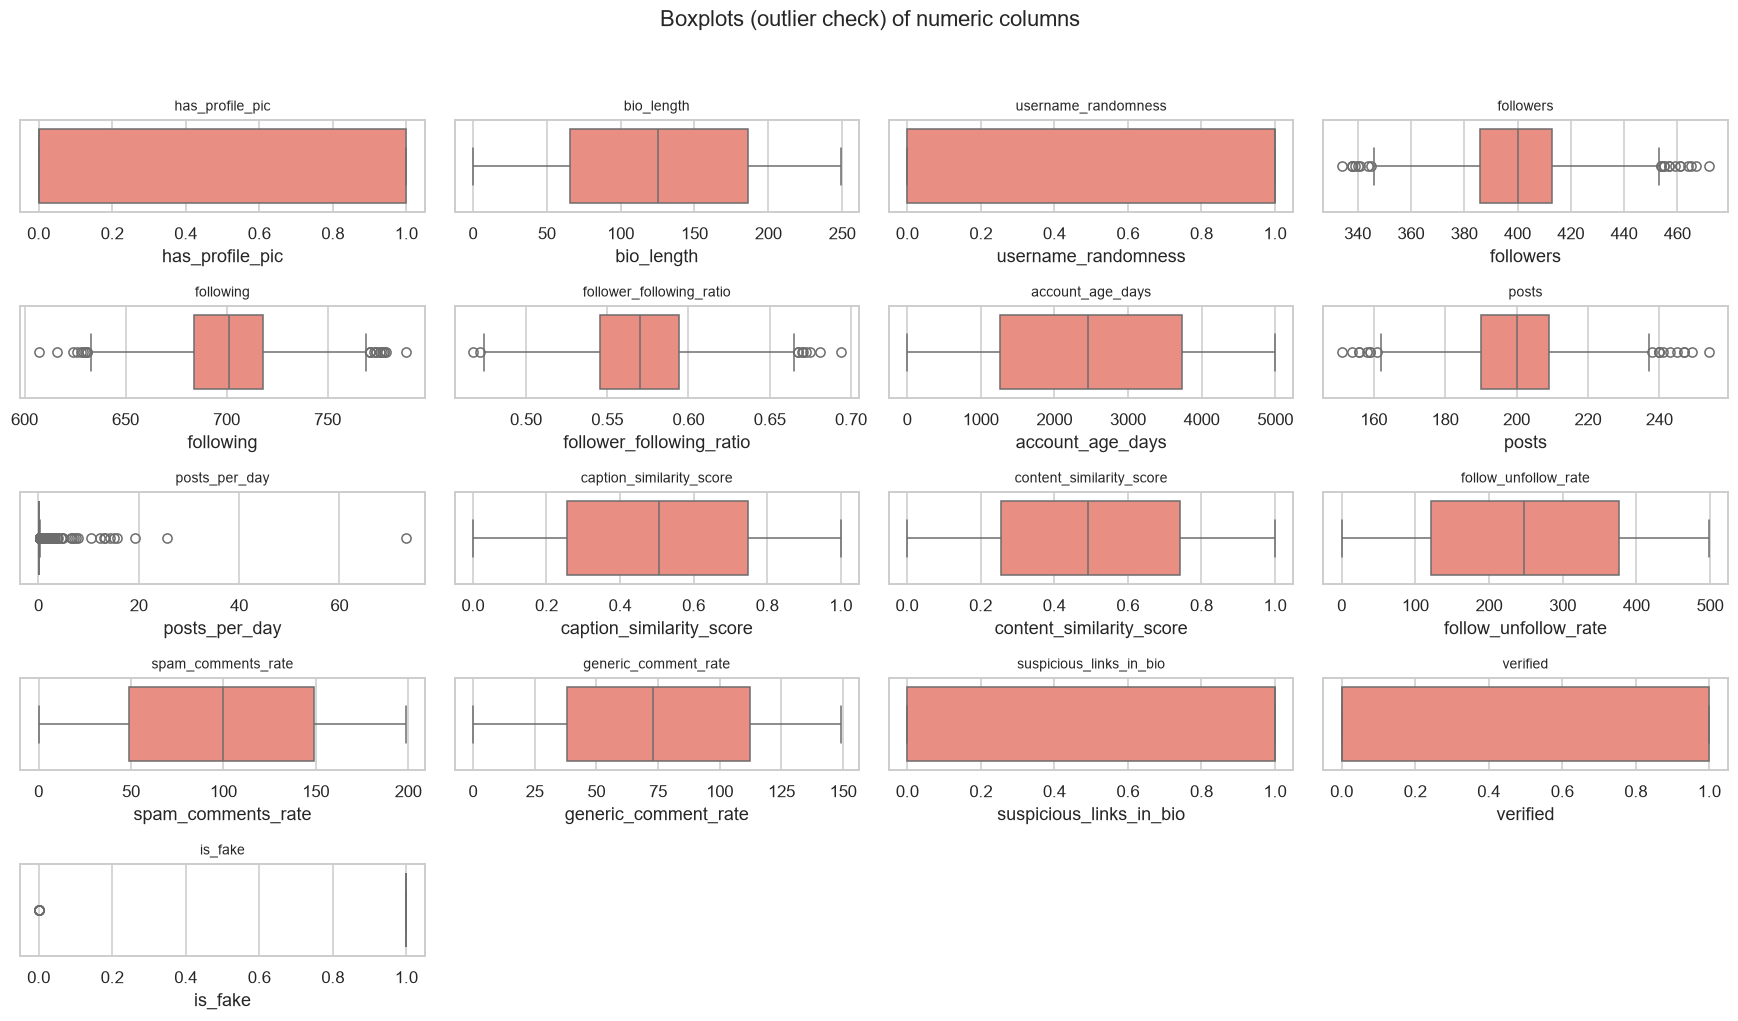

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 1.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="salmon")
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Boxplots (outlier check) of numeric columns", y=1.03)
plt.tight_layout()
plt.show()


## 6. Categorical features

In [10]:
cat_cols = [c for c in df.columns if c not in num_cols]
print(f"Non-numeric columns ({len(cat_cols)}):")
overview = pd.DataFrame({
    "nunique": [df[c].nunique(dropna=True) for c in cat_cols],
    "missing_pct": [round(df[c].isna().mean() * 100, 1) for c in cat_cols],
    "example": [str(df[c].dropna().iloc[0])[:60] if df[c].notna().any() else "-" for c in cat_cols],
}, index=cat_cols)
display(overview)


Non-numeric columns (1):


,nunique,missing_pct,example
platform,3,0.0,Twitter


Low-cardinality categorical columns: ['platform']


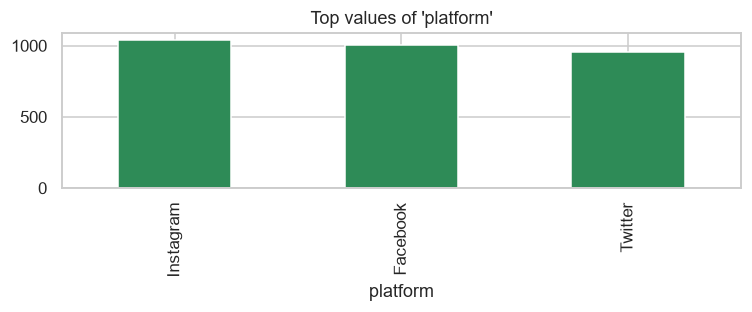

In [11]:
# Top values for the most informative low-cardinality categorical columns
low_card = [c for c in cat_cols if 1 < df[c].nunique(dropna=True) <= 30]
print("Low-cardinality categorical columns:", low_card)
for c in low_card[:8]:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[c].value_counts(dropna=False).head(15).plot.bar(ax=ax, color="seagreen")
    ax.set_title(f"Top values of '{c}'")
    plt.tight_layout()
    plt.show()


## 7. Features by class and correlation with target

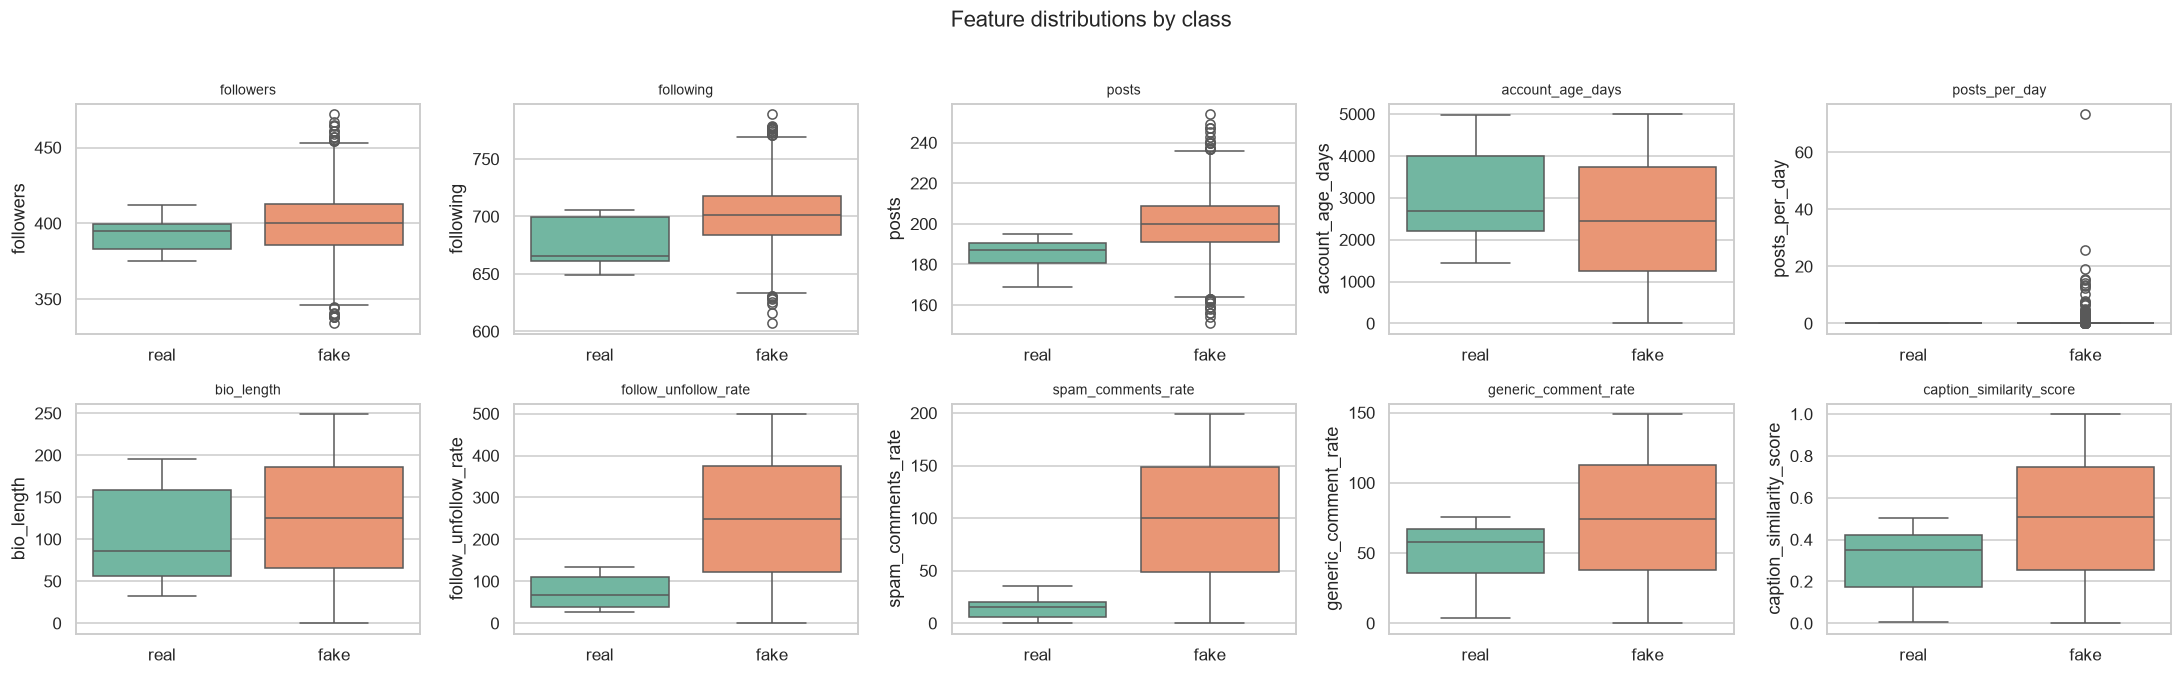

is_fake,0,1
has_profile_pic,1.000,0.488
bio_length,106.286,125.275
username_randomness,0.000,0.508
followers,392.429,399.951
following,677.429,700.727
follower_following_ratio,0.579,0.571
account_age_days,3081.714,2490.632
posts,184.714,200.292
posts_per_day,0.072,0.274
caption_similarity_score,0.292,0.501


In [12]:
# How do key features differ between real and fake accounts?
key_features = [
    "followers", "following", "posts", "account_age_days", "posts_per_day",
    "bio_length", "follow_unfollow_rate", "spam_comments_rate",
    "generic_comment_rate", "caption_similarity_score",
]
key_features = [c for c in key_features if c in df.columns]
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.ravel()
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x=label_col, y=col, hue=label_col, ax=ax,
                palette="Set2", legend=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["real", "fake"])
for ax in axes[len(key_features):]:
    ax.axis("off")
plt.suptitle("Feature distributions by class", y=1.02)
plt.tight_layout()
plt.show()

display(df.groupby(label_col)[num_cols].mean().T.round(3))


In [13]:
# Correlation of each feature with the target
target_corr = df[num_cols].corrwith(df[label_col]).sort_values(key=np.abs, ascending=False)
print(target_corr.round(3))


is_fake                     1.000
spam_comments_rate          0.071
follow_unfollow_rate        0.058
posts                       0.053
has_profile_pic            -0.049
username_randomness         0.049
suspicious_links_in_bio     0.048
following                   0.043
caption_similarity_score    0.035
verified                   -0.035
content_similarity_score    0.033
generic_comment_rate        0.028
account_age_days           -0.020
followers                   0.018
bio_length                  0.013
follower_following_ratio   -0.011
posts_per_day               0.006
dtype: float64


## 8. Key observations
- **3,000 rows x 18 columns**, fully numeric engineered features + `platform` (Twitter/Instagram) + target `is_fake`. **No missing values, no duplicates.**
- **Extreme class imbalance: 99.77% of rows are fake (2,993 fake vs 7 real)** — as-is this dataset cannot train a reliable detector; it must be rebalanced (undersampling/oversampling/SMOTE) or augmented with the real class, and metrics must be PR-AUC / recall, not accuracy.
- Several features have suspiciously narrow ranges (`followers` ~334-472, `following` ~607-789, `posts` ~151-254) suggesting synthetic generation.
- `posts_per_day` has extreme outliers (up to 73 vs median ~0.07); rate features (`follow_unfollow_rate`, `spam_comments_rate`, `generic_comment_rate`) are on unbounded scales — scaling needed.
- Similarity scores (`caption_similarity_score`, `content_similarity_score`) are roughly uniform 0-1.
- Correlation with the target is weak across the board because the target is nearly constant — re-check after rebalancing.